<a href="https://colab.research.google.com/github/DinhThanh-Dat/ThucHanhDeepLearning/blob/main/Baitaptuan4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#2. CÀI ĐẶT MÔ HÌNH AUTOENCODER

##2.1. Nạp thư viện

In [1]:
from keras.datasets import mnist
import numpy as np
import keras
from keras import layers

##2.2. Nạp dataset

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 225.
x_test = x_test.astype('float32') / 225.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print(x_train.shape)
print(x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 784)
(10000, 784)


##2.3. Xây dựng mô hình Autoencoder

In [5]:
#This is the size of encoded representations
encoding_dim = 32

#This is our input image
input_img = keras.Input(shape=(784,))

encoded = layers.Dense(encoding_dim, activation='relu')(input_img)

decoded = layers.Dense(784, activation='sigmoid')(encoded)

autoencoder = keras.Model(input_img, decoded)

encoder = keras.Model(input_img, encoded)

encoded_input = keras.Input(shape=(encoding_dim,))

decoder_layer = autoencoder.layers[-1]

decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

##2.4. Huấn luyện mô hình

In [7]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, verbose=1, shuffle=True, validation_data=(x_test, x_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.0085 - loss: 0.2675 - val_accuracy: 0.0092 - val_loss: 0.1695
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.0112 - loss: 0.1459 - val_accuracy: 0.0120 - val_loss: 0.1219
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.0111 - loss: 0.1113 - val_accuracy: 0.0114 - val_loss: 0.0965
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0109 - loss: 0.0906 - val_accuracy: 0.0092 - val_loss: 0.0791
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.0108 - loss: 0.0761 - val_accuracy: 0.0118 - val_loss: 0.0662
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0134 - loss: 0.0651 - val_accuracy: 0.0138 - val_loss: 0.0562
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0168 - loss: 0.0563 - val_accuracy: 0.0162 - val_loss: 0.0482
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0188 - loss: 0.0490 - val_accu

##2.5. Dự báo loại ảnh sử dụng Autoencoder

In [11]:
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


##2.6. Hiển thị ảnh từ mô hình Autoencoder

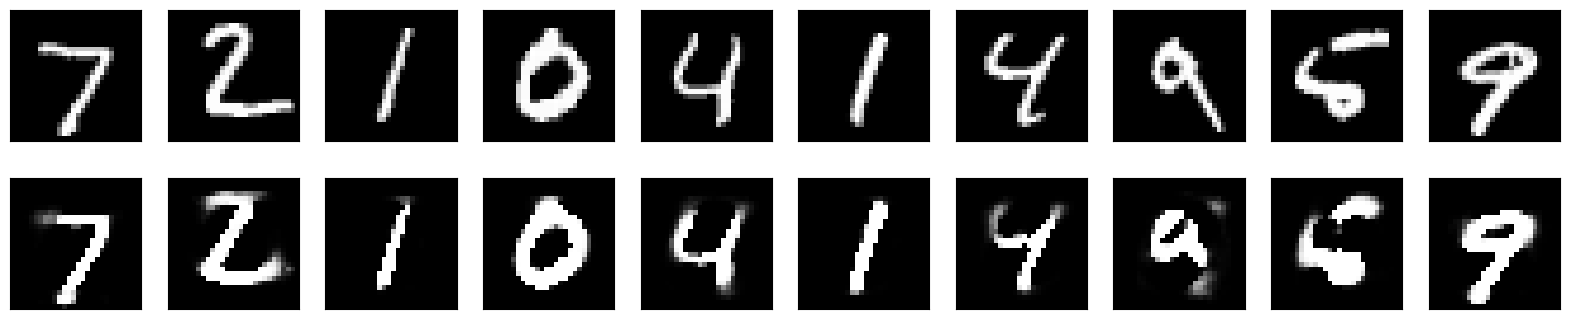

In [12]:
import matplotlib.pyplot as plt

n =10

plt.figure(figsize=(20,4))
for i in range(n):
    ax = plt.subplot(2, n, i+1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

#3. CẢI TIẾN AUTOENCODER

##3.1. Thêm L1

In [15]:
from keras import regularizers

encoding_dim = 32

input_img = keras.Input(shape=(784,))

encoded = layers.Dense(encoding_dim, activity_regularizer=regularizers.l1(10e-5), activation='relu')(input_img)

decoded = layers.Dense(784, activation='sigmoid')(encoded)

autoencoder = keras.Model(input_img, decoded)

encoder = keras.Model(input_img, encoded)

encoded_input = keras.Input(shape=(encoding_dim,))

decoder_layer = autoencoder.layers[-1]

decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

In [17]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
autoencoder.fit(x_train,x_train,epochs=100,batch_size=256, verbose=1, shuffle=True,validation_data=(x_test, x_test))

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.0140 - loss: 0.6564 - val_accuracy: 0.0161 - val_loss: 0.6179
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.0150 - loss: 0.5868 - val_accuracy: 0.0161 - val_loss: 0.5578
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.0150 - loss: 0.5328 - val_accuracy: 0.0161 - val_loss: 0.5095
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0150 - loss: 0.4893 - val_accuracy: 0.0161 - val_loss: 0.4705
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0150 - loss: 0.4542 - val_accuracy: 0.0161 - val_loss: 0.4389
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.0150 - loss: 0.4256 - val_accuracy: 0.0161 - val_loss: 0.4131
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.0150 - loss: 0.4023 - val_accuracy: 0.0161 - val_loss: 0.3920
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.0150 - loss: 0.3832 - 

##3.2. Thêm layers

In [21]:
encoding_dim =32

input_img = keras.Input(shape=(784,))

encoded = layers.Dense(128, activation='relu')(input_img)

encoded = layers.Dense(64, activation='relu')(encoded)

encoded = layers.Dense(encoding_dim, activation='relu')(encoded)

decocded = layers.Dense(784, activation='sigmoid')(encoded)

autoencoder = keras.Model(input_img, decoded)

encoder = keras.Model(input_img, encoded)
encoded_input = keras.Input(shape=(32,))

decoder_layer = autoencoder.layers[-1]

decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

